# Face Detection Pipeline

Will be using Histogram of Oriented Gradients (HOG) - feature extraction technique - which transforms image pixels into a vector representation that is sensitive to broadly informative image features (like capturing edge, contour, and texture information) regardless of confounding factors like illumination


## Example: HOG


hog_vec.shape=(153090,)


Text(0.5, 1.0, 'visualization of HOG features')

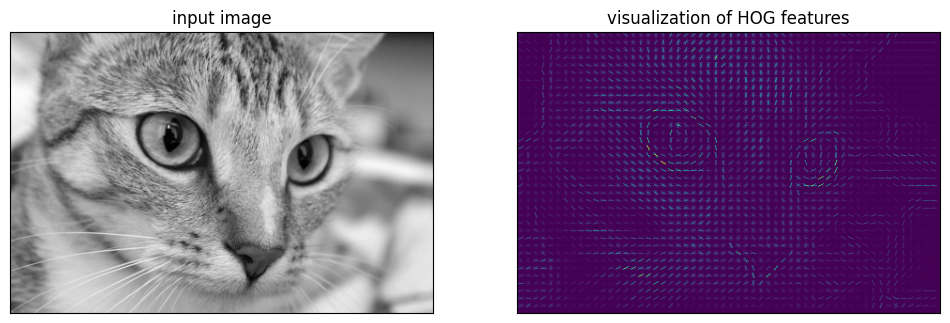

In [5]:
import matplotlib.pyplot as plt
from skimage import data, color, feature
import skimage.data

image = color.rgb2gray(data.chelsea())
hog_vec, hog_vis = feature.hog(image, visualize=True)
print(f"{hog_vec.shape=}")

fig, ax = plt.subplots(1, 2, figsize=(12, 6), subplot_kw=dict(xticks=[], yticks=[]))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("input image")
ax[1].imshow(hog_vis)
ax[1].set_title("visualization of HOG features")

## Steps:

1. Obtain a set of image thumbnails of faces to constitute “positive” training samples
2. Obtain a set of image thumbnails of nonfaces to constitute “negative” training samples
3. Extract HOG features from these training samples
4. Train a linear SVM classifier on these samples
5. For an “unknown” image, pass a sliding window across the image, using the model to evaluate whether that window contains a face or not
6. If detections overlap, combine them into a single window


## Positive training samples


In [7]:
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people()
positive_patches = faces.images
positive_patches.shape

(13233, 62, 47)

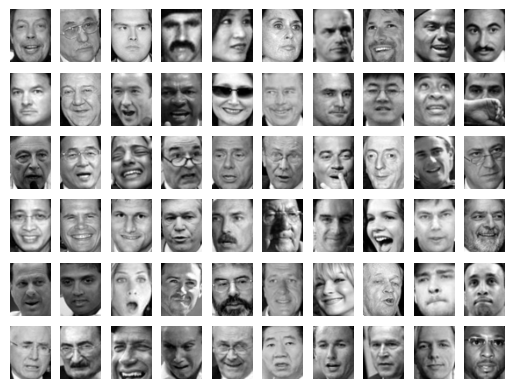

In [8]:
fig, ax = plt.subplots(6, 10)
for i, axi in enumerate(ax.flat):
    axi.imshow(positive_patches[i], cmap="gray")
    axi.axis("off")

## Negative training samples


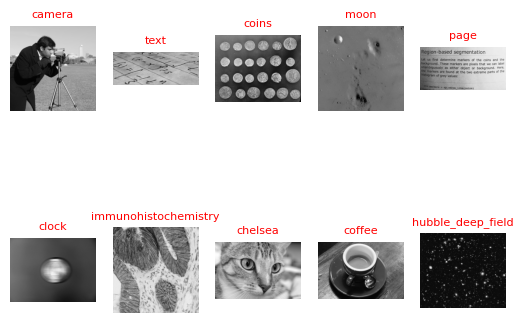

In [43]:
from skimage import data, transform

imgs_to_use = [
    "camera",
    "text",
    "coins",
    "moon",
    "page",
    "clock",
    "immunohistochemistry",
    "chelsea",
    "coffee",
    "hubble_deep_field",
]
images = []
for name in imgs_to_use:
    image = getattr(data, name)()
    if image.ndim == 3:
        # colored image with R,G,B channel
        images.append(color.rgb2gray(image))
    else:
        # gray image
        images.append(image)

fig, ax = plt.subplots(2, 5)
for i, axi in enumerate(ax.flat):
    axi.imshow(images[i], cmap="gray")
    axi.axis("off")
    axi.set_title(imgs_to_use[i], fontsize=8, color="red")

In [44]:
import numpy as np
from sklearn.feature_extraction.image import PatchExtractor


def extract_patches(img, N, scale=1.0, patch_size=positive_patches[0].shape):
    extracted_patch_size = tuple((scale * np.array(patch_size)).astype(int))
    extractor = PatchExtractor(
        patch_size=extracted_patch_size, max_patches=N, random_state=0
    )
    patches = extractor.transform(img[np.newaxis])
    if scale != 1:
        patches = np.array([transform.resize(patch, patch_size) for patch in patches])
    return patches

In [ ]:
## same size as positive samples
negative_patches = np.vstack(
    [extract_patches(im, 1000, scale) for im in images for scale in [0.5, 1.0, 2.0]]
)
negative_patches.shape

(30000, 62, 47)

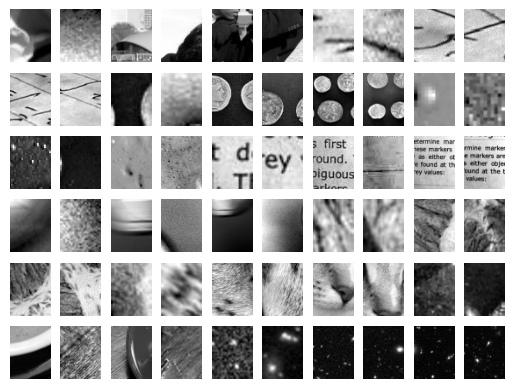

In [46]:
fig, ax = plt.subplots(6, 10)
for i, axi in enumerate(ax.flat):
    axi.imshow(negative_patches[500 * i], cmap="gray")
    axi.axis("off")

## Combine sets and extract HOG features.


In [47]:
from itertools import chain

X_train = np.array(
    [feature.hog(im) for im in chain(positive_patches, negative_patches)]
)
y_train = np.zeros(X_train.shape[0])
y_train[: positive_patches.shape[0]] = 1

In [48]:
X_train.shape

(43233, 1215)

## Train a support vector machine

- use a simple Gaussian naive Bayes to get a quick baseline
- use svm


In [49]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

cross_val_score(GaussianNB(), X_train, y_train, cv=5)

array([0.95663236, 0.972476  , 0.97363247, 0.97640527, 0.97536433])

In [50]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(LinearSVC(), {"C": [1.0, 2.0, 4.0, 8.0]})
grid.fit(X_train, y_train)
grid.best_score_

0.9888048336666179

In [51]:
grid.best_params_

{'C': 2.0}

In [52]:
model = grid.best_estimator_
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

## Find faces in a new image


(-0.5, 139.5, 159.5, -0.5)

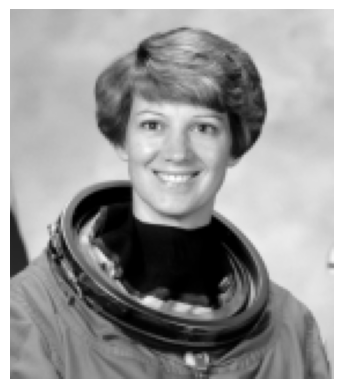

In [53]:
test_image = skimage.data.astronaut()
test_image = skimage.color.rgb2gray(test_image)
test_image = skimage.transform.rescale(test_image, 0.5)
test_image = test_image[:160, 40:180]
plt.imshow(test_image, cmap="gray")
plt.axis("off")

In [54]:
def sliding_window(
    img, patch_size=positive_patches[0].shape, istep=2, jstep=2, scale=1.0
):
    Ni, Nj = (int(scale * s) for s in patch_size)
    for i in range(0, img.shape[0] - Ni, istep):
        for j in range(0, img.shape[1] - Ni, jstep):
            patch = img[i : i + Ni, j : j + Nj]
            if scale != 1:
                patch = transform.resize(patch, patch_size)
            yield (i, j), patch


indices, patches = zip(*sliding_window(test_image))
patches_hog = np.array([feature.hog(patch) for patch in patches])
patches_hog.shape

(1911, 1215)

In [55]:
labels = model.predict(patches_hog)
labels.sum()

46.0

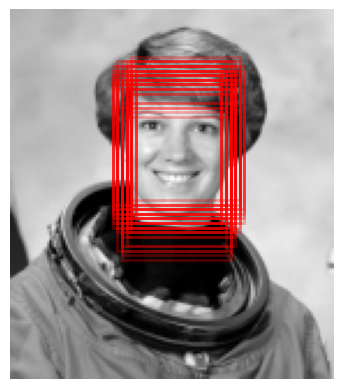

In [56]:
fig, ax = plt.subplots()
ax.imshow(test_image, cmap="gray")
ax.axis("off")
Ni, Nj = positive_patches[0].shape
indices = np.array(indices)
for i, j in indices[labels == 1]:
    ax.add_patch(
        plt.Rectangle(
            (j, i), Nj, Ni, edgecolor="red", alpha=0.3, lw=2, facecolor="none"
        )
    )

## Caveats:

- Our training set, especially for negative features, is not very complete: Our model is prone to False Positive
  - Address by adding a wider variety of images to the negative training set
  - We can use 'hard negative mining' - find all the patches representing false positives, and explicitly add them as negative instances in the training set before retraining the classifier
- Our current pipeline searches only at one scale: we made sure out training & testing data all have 62×47 pixels
- We should combine overlapped detection patches: we would prefer not to have 46 detections of the same face, but to somehow reduce overlapping groups of detections down to a single detection
